# Diagnostic des portefeuilles Black-Litterman avec vues LLM

Ce notebook produit un tableau mensuel de diagnostic pour comprendre pourquoi les portefeuilles Black-Litterman avec vues LLM sous-performent.

Il compare chaque modèle LLM à un benchmark **S&P25 cap-weighted** construit directement à partir de `data/filtered_sp25_data.csv`.

Diagnostics calculés :

- nombre de vues utilisées;
- corrélation entre vues LLM et rendements réalisés du mois suivant;
- hit rate des signes;
- rendement BL avec vues;
- rendement S&P25;
- écart actif BL - S&P25;
- active share;
- tracking error mensuel cumulatif/ex-post;
- turnover;
- concentration du portefeuille;
- poids moyen dans les titres avec vues positives/négatives.

La logique temporelle utilisée est :

```text
vues et poids du mois M -> rendement réalisé du mois M+1
```


In [13]:
# ============================
# Imports et configuration
# ============================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.options.display.float_format = "{:,.6f}".format

# -------- chemins principaux --------
DATASET_PATH = Path("../data/filtered_sp25_data.csv")
RESULTS_DIR = Path("../results")
RESPONSES_DIR = Path("../responses")

START_DATE = "2015-01-01"
END_DATE = "2025-06-30"
TAU = 0.025

# Modèles à diagnostiquer
# Adapter selon les fichiers disponibles dans results/ et responses/
MODELS = ["gpt", "gemma3", "qwen", "llama"]

# Noms attendus des fichiers de poids et de rendements
WEIGHTS_TEMPLATE = "{model}_black_litterman_market_implied_weights_tau_{tau}.csv"
RETURNS_TEMPLATE = "{model}_black_litterman_implied_weights_returns_tau_{tau}_{start}_{end}.csv"
RESPONSES_TEMPLATE = "{model}_{start}_{end}.json"

# Si tes fichiers utilisent "gemma" au lieu de "gemma3", change MODELS ci-dessus.


In [14]:
# ============================
# Fonctions utilitaires
# ============================

def clean_ticker(x):
    if x is None:
        return ""
    s = str(x).strip().strip('"').strip("'").upper()
    if not s or s in {"NAN", "NONE"}:
        return ""
    if "-" in s and "." not in s:
        s = s.replace("-", ".")
    return "".join(s.split())


def parse_dataset_dates(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        v = pd.to_numeric(s, errors="coerce")
        if np.isfinite(v).any() and np.nanmedian(v[np.isfinite(v)]) > 1_000_000:
            ss = v.astype("Int64").astype(str).str.zfill(8)
            return pd.to_datetime(ss, format="%Y%m%d", errors="coerce")
        return pd.to_datetime(v, errors="coerce")

    ss = s.astype(str).str.strip()
    out = pd.Series(pd.NaT, index=s.index)
    looks_yyyymmdd = ss.str.match(r"^\d{8}$")
    out.loc[looks_yyyymmdd] = pd.to_datetime(ss.loc[looks_yyyymmdd], format="%Y%m%d", errors="coerce")
    out.loc[~looks_yyyymmdd] = pd.to_datetime(ss.loc[~looks_yyyymmdd], errors="coerce")
    return out


def month_pairs(start_date: str, end_date: str):
    starts = pd.date_range(start=pd.to_datetime(start_date), end=pd.to_datetime(end_date), freq="MS")
    return [
        (
            d.strftime("%Y-%m-%d"),
            (d + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")
        )
        for d in starts
    ]


def load_sp25_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)

    required = {"date", "tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {path}: {sorted(missing)}")

    df = df.copy()
    df["date"] = parse_dataset_dates(df["date"])
    df = df.dropna(subset=["date"]).copy()

    df["tic"] = df["tic"].map(clean_ticker)
    df = df[df["tic"] != ""].copy()

    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")

    df["ym"] = df["date"].dt.to_period("M")
    df = df.sort_values(["tic", "ym", "date"])

    # Dernière observation disponible par titre et par mois
    df_m = df.drop_duplicates(["tic", "ym"], keep="last").copy()
    df_m["month_start"] = df_m["ym"].dt.to_timestamp()
    df_m["month_end"] = df_m["ym"].dt.to_timestamp("M")
    return df_m


def pivot_monthly(df_m: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return (
        df_m.pivot_table(index="month_start", columns="tic", values=value_col, aggfunc="last")
        .sort_index()
    )


def normalize_weights_columns(weights_df: pd.DataFrame) -> pd.DataFrame:
    df = weights_df.copy()
    if "Date" not in df.columns:
        raise ValueError("Le fichier de poids doit contenir une colonne 'Date'.")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.to_period("M").dt.to_timestamp()

    asset_cols = [c for c in df.columns if c != "Date"]
    mapping = {}
    for c in asset_cols:
        cc = clean_ticker(c)
        if cc:
            mapping.setdefault(cc, []).append(c)

    out = df[["Date"]].copy()
    for cc, cols in mapping.items():
        out[cc] = df[cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)

    return out


def load_model_weights(model: str) -> pd.DataFrame:
    path = RESULTS_DIR / WEIGHTS_TEMPLATE.format(model=model.lower(), tau=TAU)
    alt_path = RESULTS_DIR / WEIGHTS_TEMPLATE.format(model=model, tau=TAU)

    if path.exists():
        use_path = path
    elif alt_path.exists():
        use_path = alt_path
    else:
        raise FileNotFoundError(f"Fichier de poids introuvable pour {model}: {path} ou {alt_path}")

    w = pd.read_csv(use_path)
    w = normalize_weights_columns(w)
    return w


def load_model_returns(model: str) -> pd.DataFrame:
    path = RESULTS_DIR / RETURNS_TEMPLATE.format(
        model=model.lower(),
        tau=TAU,
        start=START_DATE,
        end=END_DATE
    )
    alt_path = RESULTS_DIR / RETURNS_TEMPLATE.format(
        model=model,
        tau=TAU,
        start=START_DATE,
        end=END_DATE
    )

    if path.exists():
        use_path = path
    elif alt_path.exists():
        use_path = alt_path
    else:
        raise FileNotFoundError(f"Fichier de rendements introuvable pour {model}: {path} ou {alt_path}")

    r = pd.read_csv(use_path)
    date_col = "date_key" if "date_key" in r.columns else "Date"
    ret_col = "Portfolio_Return"

    r[date_col] = pd.to_datetime(r[date_col], errors="coerce")
    r = r.dropna(subset=[date_col]).copy()
    r["month_start"] = r[date_col].dt.to_period("M").dt.to_timestamp()
    r[ret_col] = pd.to_numeric(r[ret_col], errors="coerce")

    return r[["month_start", ret_col]].rename(columns={ret_col: f"ret_{model}"})


def load_response_file(model: str, start_date: str, end_date: str) -> dict:
    path = RESPONSES_DIR / RESPONSES_TEMPLATE.format(model=model, start=start_date, end=end_date)
    alt_path = RESPONSES_DIR / RESPONSES_TEMPLATE.format(model=model.lower(), start=start_date, end=end_date)

    if path.exists():
        use_path = path
    elif alt_path.exists():
        use_path = alt_path
    else:
        return {}

    try:
        with open(use_path, "r", encoding="utf-8") as f:
            raw = json.load(f)
    except Exception:
        return {}

    out = {}
    for k, v in raw.items():
        t = clean_ticker(k)
        if t:
            out[t] = v
    return out


def extract_view_mean(response_value):
    # Cas attendu : {"expected_return": [x1, x2, ...]} ou {"expected_return": x}
    if not isinstance(response_value, dict):
        return np.nan

    x = response_value.get("expected_return", np.nan)

    if isinstance(x, list):
        vals = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy(dtype=float)
        if vals.size == 0:
            return np.nan
        return float(np.mean(vals))

    try:
        return float(x)
    except Exception:
        return np.nan


def compute_sp25_cap_weighted_returns(df_m: pd.DataFrame) -> pd.DataFrame:
    ret_wide = pivot_monthly(df_m, "stock_ret")
    cap_wide = pivot_monthly(df_m, "market_equity")

    rows = []
    months = sorted(ret_wide.index)

    for m in months:
        target_m = m + pd.offsets.MonthBegin(1)

        if target_m not in ret_wide.index:
            continue

        caps = cap_wide.loc[m].replace([np.inf, -np.inf], np.nan).dropna()
        caps = caps[caps > 0]

        if caps.empty:
            continue

        r_next = ret_wide.loc[target_m].reindex(caps.index)
        finite = np.isfinite(r_next.to_numpy(dtype=float))

        if not finite.any():
            continue

        caps_f = caps.iloc[np.where(finite)[0]]
        r_f = r_next.iloc[np.where(finite)[0]]

        w = caps_f / caps_f.sum()
        port_ret = float((w * r_f).sum())

        rows.append({
            "month_start": target_m,
            "sp25_return": port_ret,
            "weight_month": m,
            "n_sp25_assets": int(len(w))
        })

    return pd.DataFrame(rows).sort_values("month_start").reset_index(drop=True)


def compute_market_weights_for_month(df_m: pd.DataFrame, weight_month: pd.Timestamp) -> pd.Series:
    d = df_m[df_m["month_start"] == weight_month].copy()
    if d.empty:
        return pd.Series(dtype=float)

    caps = d.set_index("tic")["market_equity"].replace([np.inf, -np.inf], np.nan).dropna()
    caps = caps[caps > 0]
    if caps.empty:
        return pd.Series(dtype=float)

    return caps / caps.sum()


def concentration_hhi(w: pd.Series) -> float:
    w = pd.to_numeric(w, errors="coerce").fillna(0.0)
    return float((w ** 2).sum())


def active_share(w_model: pd.Series, w_bench: pd.Series) -> float:
    idx = w_model.index.union(w_bench.index)
    wm = w_model.reindex(idx).fillna(0.0)
    wb = w_bench.reindex(idx).fillna(0.0)
    return float(0.5 * np.abs(wm - wb).sum())


def one_way_turnover(w_t: pd.Series, w_prev: pd.Series | None) -> float:
    if w_prev is None or w_prev.empty:
        return np.nan
    idx = w_t.index.union(w_prev.index)
    wt = w_t.reindex(idx).fillna(0.0)
    wp = w_prev.reindex(idx).fillna(0.0)
    return float(0.5 * np.abs(wt - wp).sum())


In [15]:
# ============================
# Chargement du dataset et du benchmark S&P25
# ============================

df_m = load_sp25_dataset(DATASET_PATH)

ret_wide = pivot_monthly(df_m, "stock_ret")
cap_wide = pivot_monthly(df_m, "market_equity")

sp25 = compute_sp25_cap_weighted_returns(df_m)

print("Dataset mensuel:", df_m.shape)
print("Rendements wide:", ret_wide.shape)
print("Benchmark S&P25:", sp25.shape)

display(sp25.head())
display(sp25.tail())


Dataset mensuel: (2907, 34)
Rendements wide: (127, 43)
Benchmark S&P25: (126, 4)


,month_start,sp25_return,weight_month,n_sp25_assets
0,2015-01-01,-0.031310,2014-12-01,19
1,2015-02-01,0.054813,2015-01-01,21
2,2015-03-01,-0.027774,2015-02-01,20
3,2015-04-01,0.032139,2015-03-01,20
4,2015-05-01,0.007971,2015-04-01,22


,month_start,sp25_return,weight_month,n_sp25_assets
121,2025-02-01,0.005024,2025-01-01,21
122,2025-03-01,-0.080562,2025-02-01,21
123,2025-04-01,-0.000016,2025-03-01,24
124,2025-05-01,0.073087,2025-04-01,24
125,2025-06-01,0.069503,2025-05-01,23


In [16]:
# ============================
# Construction du tableau diagnostic par modèle
# ============================

all_diag = []

for model in MODELS:
    print(f"\n=== Diagnostic modèle: {model} ===")

    try:
        weights_df = load_model_weights(model)
        model_returns = load_model_returns(model)
    except Exception as e:
        print(f"[{model}] Ignoré: {e}")
        continue

    model_diag_rows = []
    prev_w_model = None

    for start_date, end_date in month_pairs(START_DATE, END_DATE):
        weight_month = pd.to_datetime(start_date).to_period("M").to_timestamp()
        target_month = weight_month + pd.offsets.MonthBegin(1)

        # Récupérer la ligne de poids du modèle
        row = weights_df.loc[weights_df["Date"] == weight_month]
        if row.empty:
            continue

        asset_cols = [c for c in weights_df.columns if c != "Date"]
        w_model = row[asset_cols].iloc[0]
        w_model = pd.to_numeric(w_model, errors="coerce").fillna(0.0)
        w_model = w_model[w_model != 0.0]

        s = float(w_model.sum())
        if np.isfinite(s) and abs(s) > 1e-12:
            w_model = w_model / s

        # Poids benchmark S&P25 du même mois de pondération
        w_sp25 = compute_market_weights_for_month(df_m, weight_month)

        # Rendements réalisés du mois cible
        if target_month not in ret_wide.index:
            continue

        r_next = ret_wide.loc[target_month]

        # Rendement modèle recomputé directement à partir des poids
        idx_model = w_model.index.intersection(r_next.dropna().index)
        if len(idx_model) > 0:
            wm = w_model.reindex(idx_model).fillna(0.0)
            rr = r_next.reindex(idx_model).astype(float)
            denom = wm.sum()
            ret_model_recomputed = float((wm * rr).sum() / denom) if abs(denom) > 1e-12 else np.nan
        else:
            ret_model_recomputed = np.nan

        # Rendement S&P25
        idx_bench = w_sp25.index.intersection(r_next.dropna().index)
        if len(idx_bench) > 0:
            wb = w_sp25.reindex(idx_bench).fillna(0.0)
            rb = r_next.reindex(idx_bench).astype(float)
            denom_b = wb.sum()
            ret_sp25 = float((wb * rb).sum() / denom_b) if abs(denom_b) > 1e-12 else np.nan
        else:
            ret_sp25 = np.nan

        # Vues LLM du mois M pour rendement M+1
        responses = load_response_file(model, start_date, end_date)

        view_map = {}
        for t, v in responses.items():
            q = extract_view_mean(v)
            if np.isfinite(q):
                view_map[t] = q

        views = pd.Series(view_map, dtype=float)

        # Corrélation views vs rendement réalisé M+1
        common_view_ret = views.index.intersection(r_next.dropna().index)
        if len(common_view_ret) >= 3:
            x = views.reindex(common_view_ret).astype(float)
            y = r_next.reindex(common_view_ret).astype(float)
            corr_view_realized = float(x.corr(y))
            hit_rate = float((np.sign(x) == np.sign(y)).mean())
        else:
            corr_view_realized = np.nan
            hit_rate = np.nan

        # Diagnostics des vues pondérées
        common_view_weight = views.index.intersection(w_model.index)
        if len(common_view_weight) > 0:
            vw = views.reindex(common_view_weight).astype(float)
            ww = w_model.reindex(common_view_weight).fillna(0.0).astype(float)

            avg_view_equal = float(vw.mean())
            avg_view_weighted = float((vw * ww).sum() / ww.sum()) if abs(ww.sum()) > 1e-12 else np.nan

            pos_names = vw[vw > 0].index
            neg_names = vw[vw < 0].index
            weight_positive_views = float(w_model.reindex(pos_names).fillna(0.0).sum()) if len(pos_names) else 0.0
            weight_negative_views = float(w_model.reindex(neg_names).fillna(0.0).sum()) if len(neg_names) else 0.0
        else:
            avg_view_equal = np.nan
            avg_view_weighted = np.nan
            weight_positive_views = np.nan
            weight_negative_views = np.nan

        # Diagnostics portefeuille
        ashare = active_share(w_model, w_sp25)
        turnover = one_way_turnover(w_model, prev_w_model)
        hhi = concentration_hhi(w_model)

        top5_weight = float(w_model.sort_values(ascending=False).head(5).sum()) if not w_model.empty else np.nan
        n_nonzero = int((w_model.abs() > 1e-8).sum())

        model_diag_rows.append({
            "model": model,
            "weight_month": weight_month,
            "return_month": target_month,
            "n_views": int(len(views)),
            "n_weights_nonzero": n_nonzero,
            "n_sp25_assets": int(len(w_sp25)),
            "corr_views_vs_realized_next_month": corr_view_realized,
            "hit_rate_sign_views": hit_rate,
            "avg_view_equal_weight": avg_view_equal,
            "avg_view_portfolio_weighted": avg_view_weighted,
            "weight_positive_views": weight_positive_views,
            "weight_negative_views": weight_negative_views,
            "ret_model_recomputed": ret_model_recomputed,
            "ret_sp25": ret_sp25,
            "active_return_vs_sp25": ret_model_recomputed - ret_sp25 if np.isfinite(ret_model_recomputed) and np.isfinite(ret_sp25) else np.nan,
            "active_share_vs_sp25": ashare,
            "turnover_one_way": turnover,
            "hhi_concentration": hhi,
            "top5_weight": top5_weight,
        })

        prev_w_model = w_model.copy()

    diag_model = pd.DataFrame(model_diag_rows)

    # Ajouter rendement officiel du fichier returns_from_weights pour comparaison
    if not diag_model.empty:
        diag_model = diag_model.merge(
            model_returns.rename(columns={f"ret_{model}": "ret_model_file"}),
            left_on="return_month",
            right_on="month_start",
            how="left"
        ).drop(columns=["month_start"], errors="ignore")

        diag_model["diff_recomputed_vs_file"] = diag_model["ret_model_recomputed"] - diag_model["ret_model_file"]

        # Tracking error ex-post annualisé sur fenêtre complète du modèle
        ar = diag_model["active_return_vs_sp25"].dropna()
        te_monthly = float(ar.std(ddof=1)) if len(ar) >= 2 else np.nan
        te_annualized = te_monthly * np.sqrt(12) if np.isfinite(te_monthly) else np.nan
        diag_model["tracking_error_annualized_full_sample"] = te_annualized

    all_diag.append(diag_model)

diag = pd.concat(all_diag, ignore_index=True) if all_diag else pd.DataFrame()

print("Diagnostic final:", diag.shape)
display(diag.head())



=== Diagnostic modèle: gpt ===

=== Diagnostic modèle: gemma3 ===

=== Diagnostic modèle: qwen ===

=== Diagnostic modèle: llama ===
Diagnostic final: (500, 22)


,model,weight_month,return_month,n_views,n_weights_nonzero,n_sp25_assets,corr_views_vs_realized_next_month,hit_rate_sign_views,avg_view_equal_weight,avg_view_portfolio_weighted,weight_positive_views,weight_negative_views,ret_model_recomputed,ret_sp25,active_return_vs_sp25,active_share_vs_sp25,turnover_one_way,hhi_concentration,top5_weight,ret_model_file,diff_recomputed_vs_file,tracking_error_annualized_full_sample
0,gpt,2015-01-01,2015-02-01,21,19,21,-0.020182,0.190476,-0.020857,-0.016179,0.308225,0.691775,0.051600,0.054813,-0.003214,0.245964,NaN,0.058992,0.382938,0.051600,0.000000,0.094079
1,gpt,2015-02-01,2015-03-01,20,8,21,0.476749,0.550000,0.000412,0.000864,0.667129,0.332871,-0.019790,-0.027774,0.007984,0.666751,0.632946,0.183960,0.844509,-0.019790,-0.000000,0.094079
2,gpt,2015-03-01,2015-04-01,22,7,20,-0.200093,0.363636,-0.000544,-0.004418,0.164268,0.835732,-0.001854,0.032139,-0.033994,0.688081,0.122005,0.231279,0.910257,-0.001854,-0.000000,0.094079
3,gpt,2015-04-01,2015-05-01,23,14,22,0.054434,0.521739,0.005469,-0.000564,0.497082,0.502918,-0.000502,0.007971,-0.008473,0.563930,0.212412,0.139626,0.729519,-0.000502,-0.000000,0.094079
4,gpt,2015-05-01,2015-06-01,22,17,23,0.250078,0.636364,0.001887,-0.005696,0.234798,0.765202,-0.026173,-0.024744,-0.001429,0.510376,0.301926,0.107074,0.630562,-0.026173,-0.000000,0.094079


In [17]:
# ============================
# Sauvegarde du tableau diagnostic
# ============================

OUT_DIR = Path("diagnostics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

diag_path = OUT_DIR / f"bl_llm_diagnostic_table_tau_{TAU}_{START_DATE}_{END_DATE}.csv"
diag.to_csv(diag_path, index=False)

print(f"Tableau diagnostic sauvegardé ici: {diag_path}")
display(diag.tail())


Tableau diagnostic sauvegardé ici: diagnostics\bl_llm_diagnostic_table_tau_0.025_2015-01-01_2025-06-30.csv


,model,weight_month,return_month,n_views,n_weights_nonzero,n_sp25_assets,corr_views_vs_realized_next_month,hit_rate_sign_views,avg_view_equal_weight,avg_view_portfolio_weighted,weight_positive_views,weight_negative_views,ret_model_recomputed,ret_sp25,active_return_vs_sp25,active_share_vs_sp25,turnover_one_way,hhi_concentration,top5_weight,ret_model_file,diff_recomputed_vs_file,tracking_error_annualized_full_sample
495,llama,2025-01-01,2025-02-01,22,9,23,0.234249,0.545455,-0.014251,-0.016887,0.047821,0.952179,-0.015259,0.005024,-0.020283,0.746149,0.271645,0.151699,0.789884,-0.015259,-0.000000,0.122113
496,llama,2025-02-01,2025-03-01,24,11,22,-0.134652,0.708333,-0.019523,-0.017391,0.000000,1.000000,-0.024371,-0.080562,0.056191,0.734642,0.175450,0.130607,0.752299,-0.024371,-0.000000,0.122113
497,llama,2025-03-01,2025-04-01,24,9,24,0.186491,0.500000,-0.017845,-0.017273,0.022402,0.977598,-0.046086,-0.000016,-0.046070,0.800540,0.254273,0.158489,0.859760,-0.046086,-0.000000,0.122113
498,llama,2025-04-01,2025-05-01,24,7,24,0.075459,0.333333,-0.017921,-0.030846,0.000000,1.000000,-0.060405,0.073087,-0.133491,0.841871,0.487006,0.240772,0.942158,-0.060405,-0.000000,0.122113
499,llama,2025-05-01,2025-06-01,24,6,24,-0.031252,0.291667,-0.015726,-0.032495,0.000000,1.000000,0.031430,0.069503,-0.038073,0.873240,0.205181,0.293044,0.969995,0.031430,0.000000,0.122113


In [18]:
# ============================
# Résumé par modèle
# ============================

summary = (
    diag.groupby("model")
    .agg(
        n_months=("return_month", "count"),
        avg_active_return_monthly=("active_return_vs_sp25", "mean"),
        cumulative_model_return=("ret_model_recomputed", lambda x: float((1 + x.dropna()).prod() - 1)),
        cumulative_sp25_return=("ret_sp25", lambda x: float((1 + x.dropna()).prod() - 1)),
        avg_corr_views_realized=("corr_views_vs_realized_next_month", "mean"),
        median_corr_views_realized=("corr_views_vs_realized_next_month", "median"),
        avg_hit_rate=("hit_rate_sign_views", "mean"),
        avg_active_share=("active_share_vs_sp25", "mean"),
        avg_turnover=("turnover_one_way", "mean"),
        avg_hhi=("hhi_concentration", "mean"),
        avg_top5_weight=("top5_weight", "mean"),
        avg_n_views=("n_views", "mean"),
        max_abs_diff_recomputed_vs_file=("diff_recomputed_vs_file", lambda x: float(np.nanmax(np.abs(x))) if len(x.dropna()) else np.nan),
        tracking_error_annualized=("tracking_error_annualized_full_sample", "first"),
    )
    .reset_index()
)

summary["cumulative_active_return"] = summary["cumulative_model_return"] - summary["cumulative_sp25_return"]

display(summary)


,model,n_months,avg_active_return_monthly,cumulative_model_return,cumulative_sp25_return,avg_corr_views_realized,median_corr_views_realized,avg_hit_rate,avg_active_share,avg_turnover,avg_hhi,avg_top5_weight,avg_n_views,max_abs_diff_recomputed_vs_file,tracking_error_annualized,cumulative_active_return
0,gemma3,125,-0.003748,2.427513,4.278999,0.001454,0.004135,0.550490,0.560776,0.343932,0.116539,0.633752,22.928000,0.000000,0.095353,-1.851486
1,gpt,125,-0.003957,2.282094,4.278999,0.006934,0.011974,0.533207,0.546812,0.299000,0.125847,0.661962,22.928000,0.000000,0.094079,-1.996905
2,llama,125,-0.004588,2.057790,4.278999,0.008464,-0.008601,0.434849,0.743605,0.307073,0.210132,0.858529,22.928000,0.000000,0.122113,-2.221208
3,qwen,125,-0.005657,1.534562,4.278999,-0.003282,-0.060426,0.485832,0.770789,0.558813,0.298230,0.924112,22.928000,0.000000,0.136859,-2.744437


In [19]:
# ============================
# Mois où chaque modèle sous-performe le plus
# ============================

worst_months = (
    diag.sort_values(["model", "active_return_vs_sp25"])
    .groupby("model")
    .head(10)
    .loc[:, [
        "model", "weight_month", "return_month",
        "active_return_vs_sp25",
        "ret_model_recomputed", "ret_sp25",
        "corr_views_vs_realized_next_month",
        "hit_rate_sign_views",
        "active_share_vs_sp25",
        "turnover_one_way",
        "top5_weight",
        "n_views"
    ]]
)

display(worst_months)


,model,weight_month,return_month,active_return_vs_sp25,ret_model_recomputed,ret_sp25,corr_views_vs_realized_next_month,hit_rate_sign_views,active_share_vs_sp25,turnover_one_way,top5_weight,n_views
220,gemma3,2022-12-01,2023-01-01,-0.115586,-0.037273,0.078313,-0.697721,0.333333,0.833710,0.242717,0.972023,24
214,gemma3,2022-06-01,2022-07-01,-0.104318,0.024604,0.128922,-0.175023,0.714286,0.776454,0.464979,0.815391,21
206,gemma3,2021-10-01,2021-11-01,-0.071757,-0.061031,0.010726,0.473492,0.347826,0.664048,0.434194,0.561785,23
224,gemma3,2023-04-01,2023-05-01,-0.054898,-0.001630,0.053267,-0.395171,0.291667,0.727465,0.324997,0.834188,24
222,gemma3,2023-02-01,2023-03-01,-0.049847,0.036636,0.086483,-0.156099,0.708333,0.635842,0.406715,0.713165,24
248,gemma3,2025-04-01,2025-05-01,-0.047521,0.025566,0.073087,0.133079,0.708333,0.619211,0.257438,0.456543,24
189,gemma3,2020-05-01,2020-06-01,-0.046043,-0.003727,0.042316,0.320843,0.500000,0.620432,0.603612,0.904468,22
236,gemma3,2024-04-01,2024-05-01,-0.045956,0.030334,0.076290,0.324236,0.800000,0.702876,0.425003,0.754209,25
172,gemma3,2018-12-01,2019-01-01,-0.044788,0.025771,0.070559,-0.590225,0.739130,0.608339,0.392431,0.692016,24
195,gemma3,2020-11-01,2020-12-01,-0.039201,0.005197,0.044398,0.303283,0.684211,0.550839,0.188415,0.659154,19


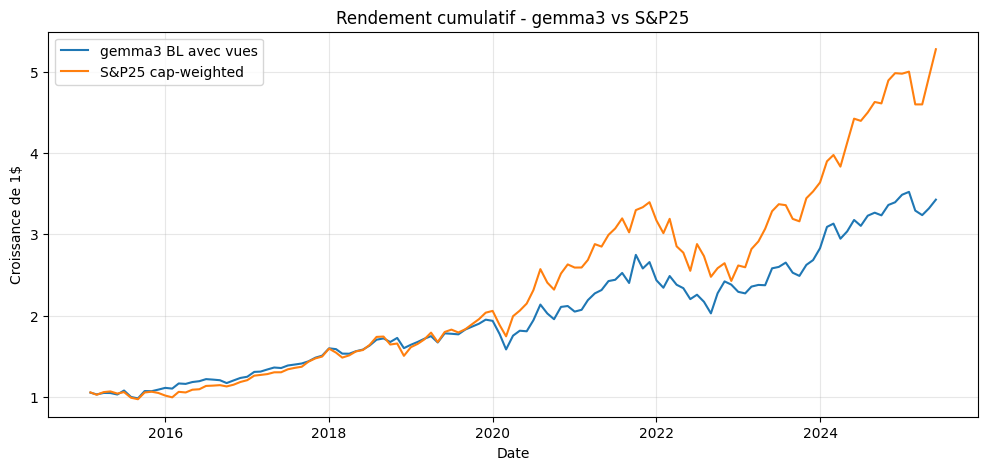

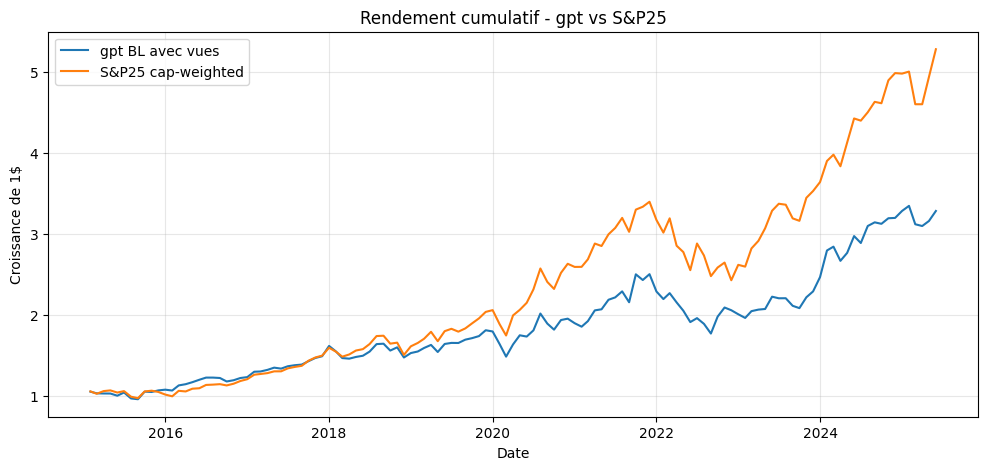

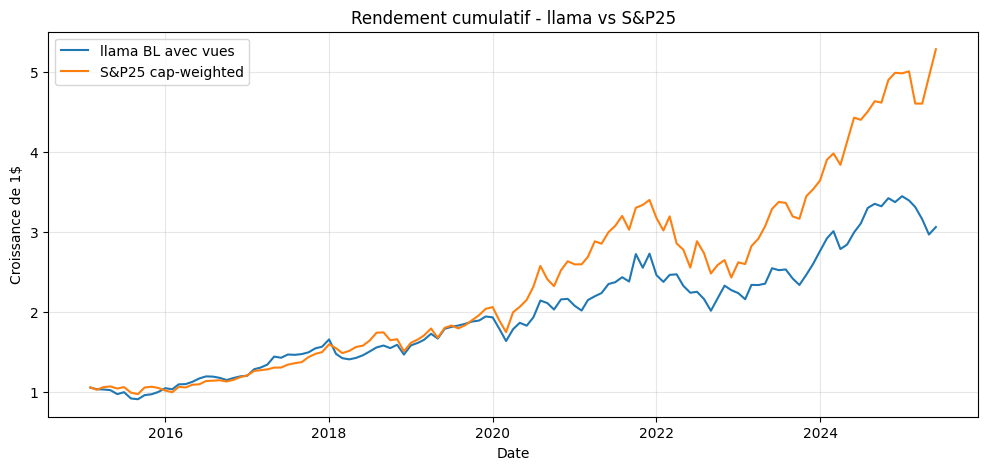

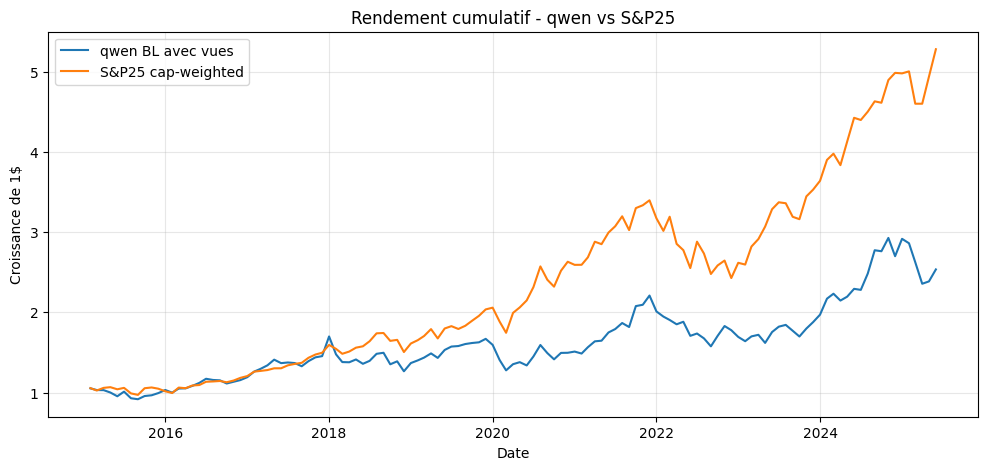

In [20]:
# ============================
# Graphique : rendement cumulatif par modèle vs S&P25
# ============================

for model in sorted(diag["model"].dropna().unique()):
    d = diag[diag["model"] == model].copy().sort_values("return_month")
    d = d.dropna(subset=["ret_model_recomputed", "ret_sp25"])

    if d.empty:
        continue

    cum_model = (1 + d["ret_model_recomputed"]).cumprod()
    cum_sp25 = (1 + d["ret_sp25"]).cumprod()

    plt.figure(figsize=(12, 5))
    plt.plot(d["return_month"], cum_model, label=f"{model} BL avec vues")
    plt.plot(d["return_month"], cum_sp25, label="S&P25 cap-weighted")
    plt.title(f"Rendement cumulatif - {model} vs S&P25")
    plt.xlabel("Date")
    plt.ylabel("Croissance de 1$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


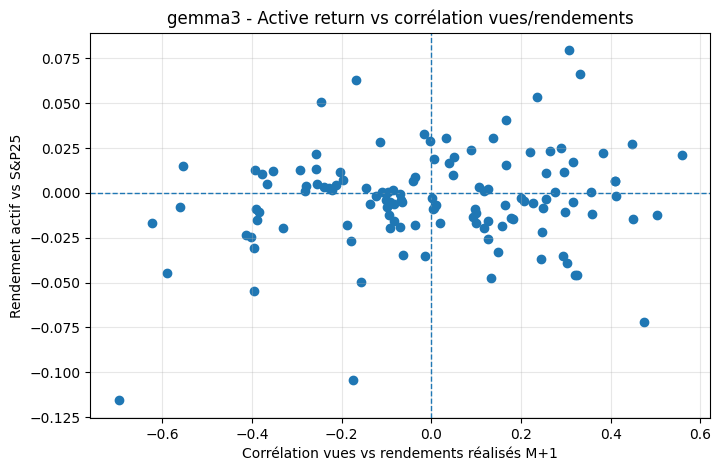

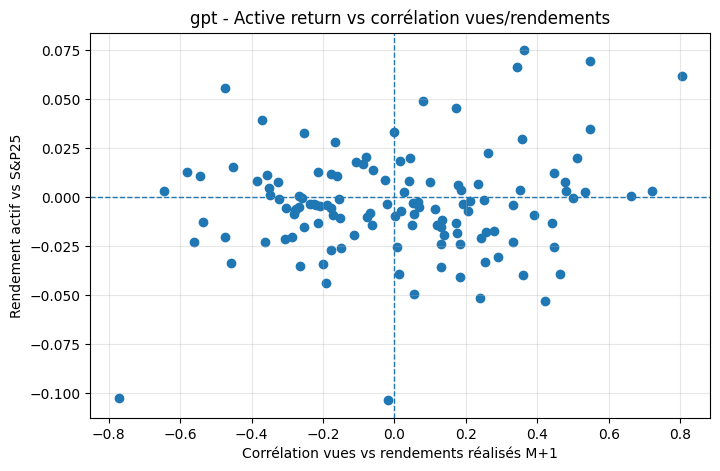

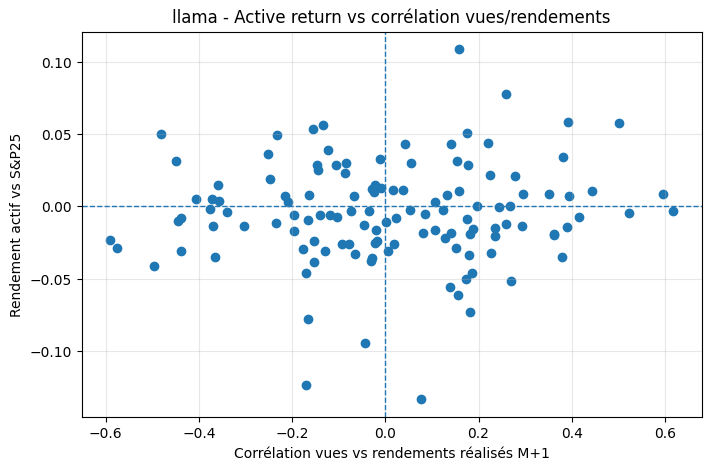

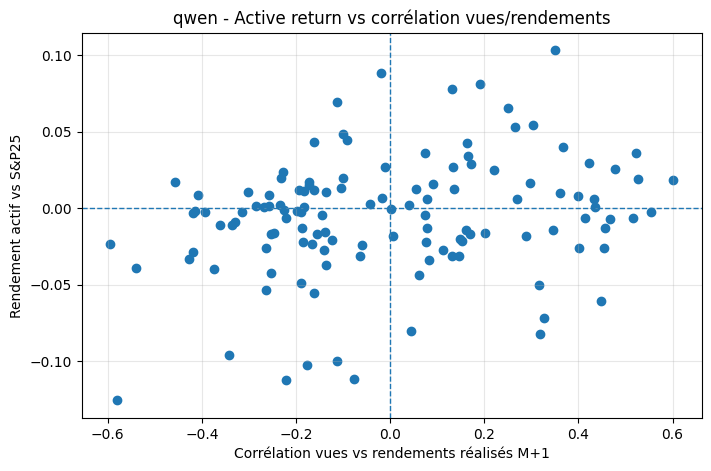

In [21]:
# ============================
# Graphique : active return mensuel vs corrélation des vues
# ============================

for model in sorted(diag["model"].dropna().unique()):
    d = diag[diag["model"] == model].copy()
    d = d.dropna(subset=["active_return_vs_sp25", "corr_views_vs_realized_next_month"])

    if d.empty:
        continue

    plt.figure(figsize=(8, 5))
    plt.scatter(d["corr_views_vs_realized_next_month"], d["active_return_vs_sp25"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title(f"{model} - Active return vs corrélation vues/rendements")
    plt.xlabel("Corrélation vues vs rendements réalisés M+1")
    plt.ylabel("Rendement actif vs S&P25")
    plt.grid(True, alpha=0.3)
    plt.show()


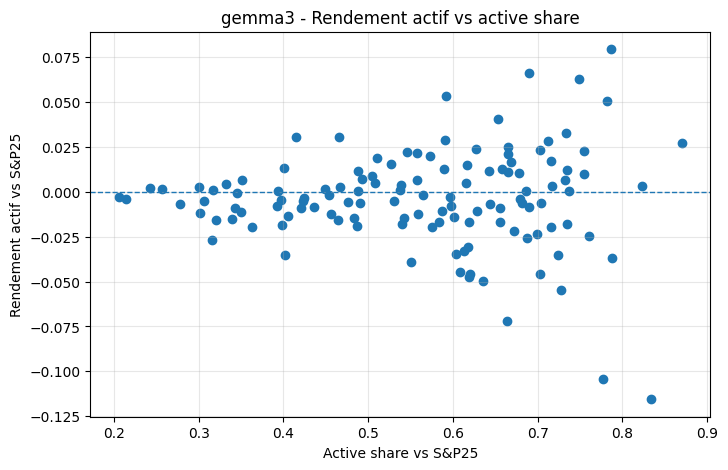

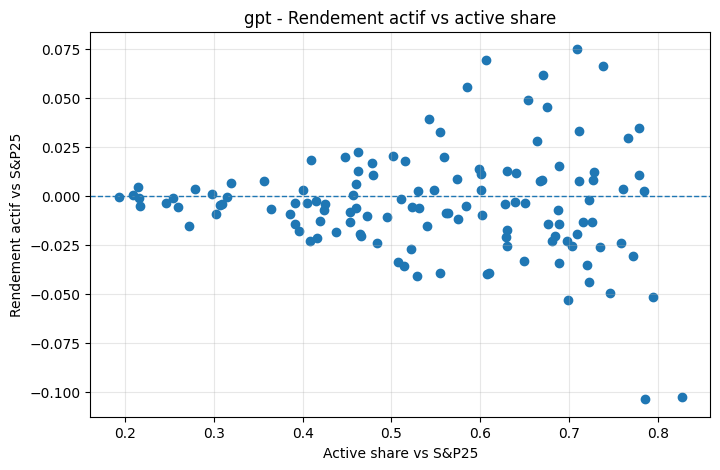

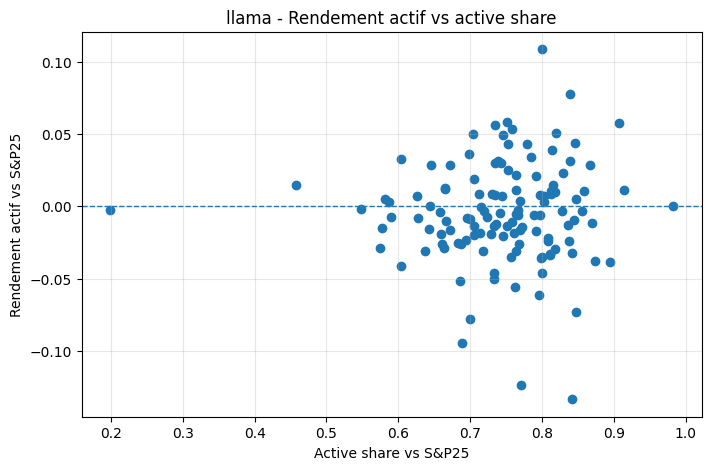

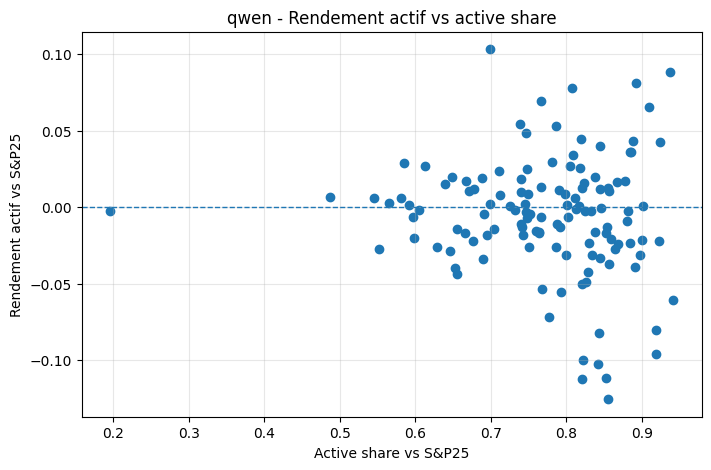

In [22]:
# ============================
# Graphique : active return vs active share
# ============================

for model in sorted(diag["model"].dropna().unique()):
    d = diag[diag["model"] == model].copy()
    d = d.dropna(subset=["active_return_vs_sp25", "active_share_vs_sp25"])

    if d.empty:
        continue

    plt.figure(figsize=(8, 5))
    plt.scatter(d["active_share_vs_sp25"], d["active_return_vs_sp25"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{model} - Rendement actif vs active share")
    plt.xlabel("Active share vs S&P25")
    plt.ylabel("Rendement actif vs S&P25")
    plt.grid(True, alpha=0.3)
    plt.show()


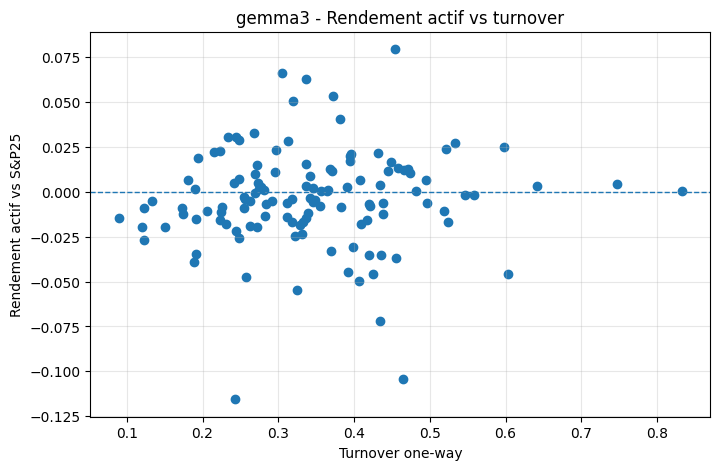

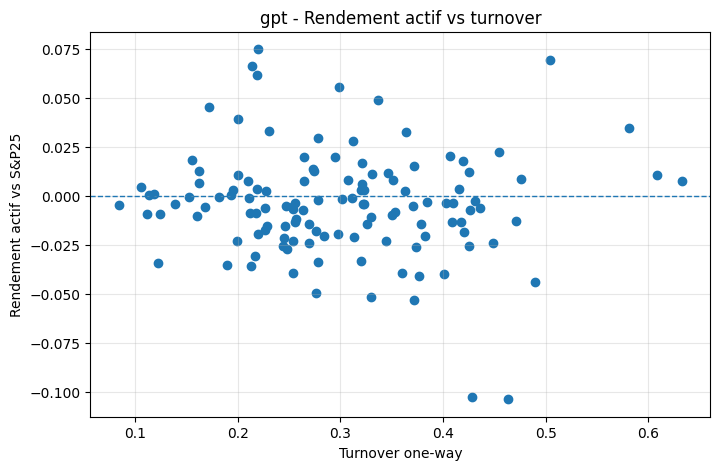

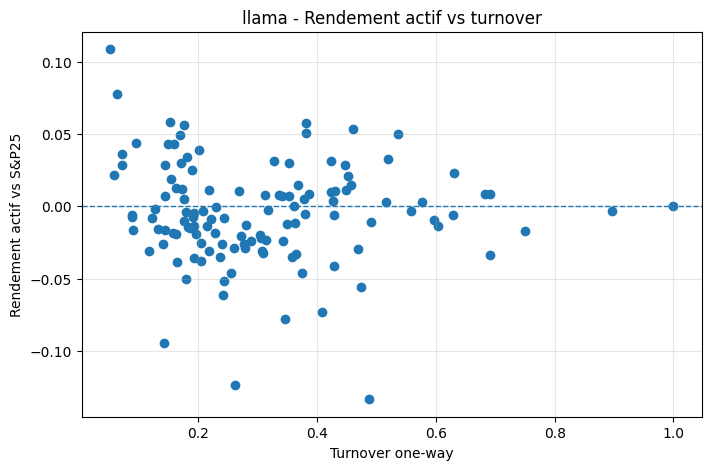

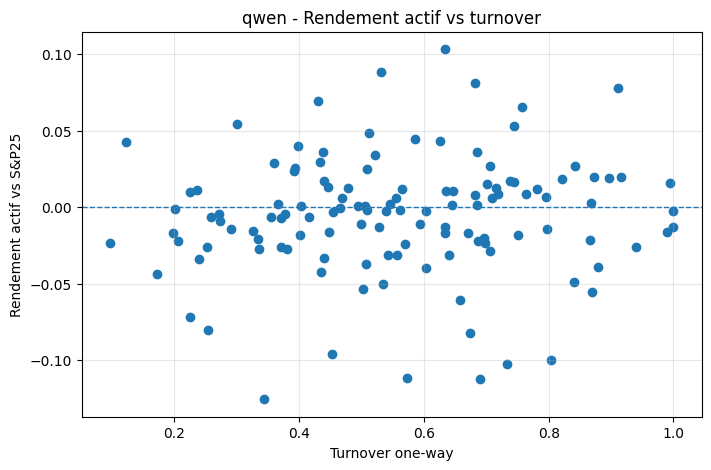

In [23]:
# ============================
# Graphique : turnover et active return
# ============================

for model in sorted(diag["model"].dropna().unique()):
    d = diag[diag["model"] == model].copy()
    d = d.dropna(subset=["active_return_vs_sp25", "turnover_one_way"])

    if d.empty:
        continue

    plt.figure(figsize=(8, 5))
    plt.scatter(d["turnover_one_way"], d["active_return_vs_sp25"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{model} - Rendement actif vs turnover")
    plt.xlabel("Turnover one-way")
    plt.ylabel("Rendement actif vs S&P25")
    plt.grid(True, alpha=0.3)
    plt.show()


In [24]:
# ============================
# Export Excel optionnel avec plusieurs onglets
# ============================

excel_path = OUT_DIR / f"bl_llm_diagnostic_report_tau_{TAU}_{START_DATE}_{END_DATE}.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    diag.to_excel(writer, sheet_name="monthly_diagnostic", index=False)
    summary.to_excel(writer, sheet_name="summary_by_model", index=False)
    worst_months.to_excel(writer, sheet_name="worst_months", index=False)

print(f"Rapport Excel sauvegardé ici: {excel_path}")


Rapport Excel sauvegardé ici: diagnostics\bl_llm_diagnostic_report_tau_0.025_2015-01-01_2025-06-30.xlsx
